In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

1. Load dataset

In [2]:
FILE_PATH = "Mahanadi_Riverbank_Erosion_2018_2024_ML_Ready.csv"

df = pd.read_csv(FILE_PATH)

print("DATASET LOADED")

DATASET LOADED


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (6000, 11)

Columns:
['NDVI', 'NDWI', 'Elevation', 'Rainfall', 'LandCover', 'Distance_From_River', 'Label', 'Feature_Year', 'Prediction_Year', 'Latitude', 'Longitude']


2. Basic information

In [4]:
print("DATASET INFORMATION")
print(df.info())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NDVI                 6000 non-null   float64
 1   NDWI                 6000 non-null   float64
 2   Elevation            6000 non-null   int64  
 3   Rainfall             6000 non-null   float64
 4   LandCover            6000 non-null   int64  
 5   Distance_From_River  6000 non-null   float64
 6   Label                6000 non-null   int64  
 7   Feature_Year         6000 non-null   int64  
 8   Prediction_Year      6000 non-null   int64  
 9   Latitude             6000 non-null   float64
 10  Longitude            6000 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 515.8 KB
None


3. First few rows

In [5]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
       NDVI      NDWI  Elevation     Rainfall  LandCover  Distance_From_River  \
0 -0.193380  0.431204        188  1817.867509          0             0.000000   
1  0.460902 -0.478127        177  1837.575458          4          1060.660172   
2  0.477690 -0.500833        167  1883.515178          4           875.956620   
3 -0.256851  0.460774        188  1879.656287          0             0.000000   
4  0.692994 -0.642158        182  1864.480601          1           934.344690   

   Label  Feature_Year  Prediction_Year   Latitude  Longitude  
0      0          2018             2019  21.582788  83.877540  
1      0          2018             2019  21.542454  84.092327  
2      0          2018             2019  21.465289  84.039236  
3      0          2018             2019  21.569314  83.973120  
4      0          2018             2019  21.471218  83.985158  


4. Check missing values

In [6]:
print("MISSING VALUES")
missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal missing values:",
    missing_values.sum()
)

MISSING VALUES
NDVI                   0
NDWI                   0
Elevation              0
Rainfall               0
LandCover              0
Distance_From_River    0
Label                  0
Feature_Year           0
Prediction_Year        0
Latitude               0
Longitude              0
dtype: int64

Total missing values: 0


5. Check duplicates

In [7]:
print("DUPLICATES")
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

DUPLICATES
Duplicate rows: 0


6. Summary statistics

In [8]:
print("SUMMARY STATISTICS")
print(df.describe())

SUMMARY STATISTICS
              NDVI         NDWI    Elevation     Rainfall    LandCover  \
count  6000.000000  6000.000000  6000.000000  6000.000000  6000.000000   
mean      0.287480    -0.244276   175.126000  1692.765117     1.566167   
std       0.252036     0.298913    30.885759   164.487955     2.014439   
min      -0.403923    -0.683592   123.000000  1425.125936     0.000000   
25%       0.079607    -0.489451   156.000000  1540.388427     0.000000   
50%       0.330318    -0.370212   172.000000  1660.807395     1.000000   
75%       0.491376     0.020540   190.000000  1830.135015     4.000000   
max       0.790647     0.580381   513.000000  2031.338850     7.000000   

       Distance_From_River        Label  Feature_Year  Prediction_Year  \
count          6000.000000  6000.000000   6000.000000      6000.000000   
mean            339.213212     0.500000   2020.500000      2021.500000   
std             446.070409     0.500042      1.707967         1.707967   
min               

7. Target class distribution

In [9]:
print("TARGET CLASS DISTRIBUTION")
print(
    df["Label"]
    .value_counts()
    .sort_index()
)


TARGET CLASS DISTRIBUTION
Label
0    3000
1    3000
Name: count, dtype: int64


In [10]:
print("\nPercentage distribution:")

print(
    df["Label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)


Percentage distribution:
Label
0    50.0
1    50.0
Name: proportion, dtype: float64


8. Target class plot

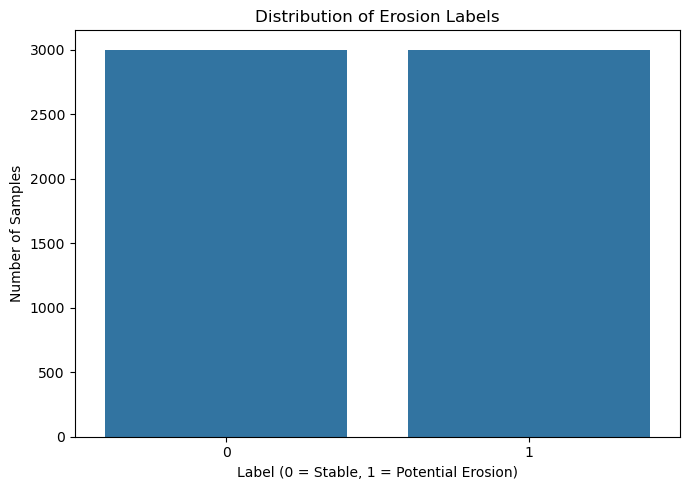

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Label"
)

plt.title(
    "Distribution of Erosion Labels"
)

plt.xlabel(
    "Label (0 = Stable, 1 = Potential Erosion)"
)

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()

plt.show()

9. Year distribution

In [12]:
print("YEAR DISTRIBUTION")
year_counts = (
    df.groupby(
        ["Feature_Year", "Prediction_Year"]
    )
    .size()
)

print(year_counts)

YEAR DISTRIBUTION
Feature_Year  Prediction_Year
2018          2019               1000
2019          2020               1000
2020          2021               1000
2021          2022               1000
2022          2023               1000
2023          2024               1000
dtype: int64


10. Year+Class distribution

In [13]:
print("\nYear-wise class distribution:")

year_class_distribution = pd.crosstab(
    df["Feature_Year"],
    df["Label"]
)

print(year_class_distribution)



Year-wise class distribution:
Label           0    1
Feature_Year          
2018          500  500
2019          500  500
2020          500  500
2021          500  500
2022          500  500
2023          500  500


11. Numerical features

In [14]:
numerical_features = [
    "NDVI",
    "NDWI",
    "Elevation",
    "Rainfall",
    "Distance_From_River"
]

print("NUMERICAL FEATURES")
print(numerical_features)

NUMERICAL FEATURES
['NDVI', 'NDWI', 'Elevation', 'Rainfall', 'Distance_From_River']


12. Numerical summary

In [15]:
print("\nNumerical feature statistics:")

print(
    df[numerical_features]
    .describe()
    .T
)


Numerical feature statistics:
                      count         mean         std          min  \
NDVI                 6000.0     0.287480    0.252036    -0.403923   
NDWI                 6000.0    -0.244276    0.298913    -0.683592   
Elevation            6000.0   175.126000   30.885759   123.000000   
Rainfall             6000.0  1692.765117  164.487955  1425.125936   
Distance_From_River  6000.0   339.213212  446.070409     0.000000   

                             25%          50%          75%          max  
NDVI                    0.079607     0.330318     0.491376     0.790647  
NDWI                   -0.489451    -0.370212     0.020540     0.580381  
Elevation             156.000000   172.000000   190.000000   513.000000  
Rainfall             1540.388427  1660.807395  1830.135015  2031.338850  
Distance_From_River    14.142136    30.000000   627.773829  1280.000000  


13. Land cover distribution

In [16]:
print("LAND COVER DISTRIBUTION")
print(
    df["LandCover"]
    .value_counts()
    .sort_index()
)


LAND COVER DISTRIBUTION
LandCover
0    2921
1    1265
3      87
4    1107
5     291
6     315
7      14
Name: count, dtype: int64


14. Land cover plot

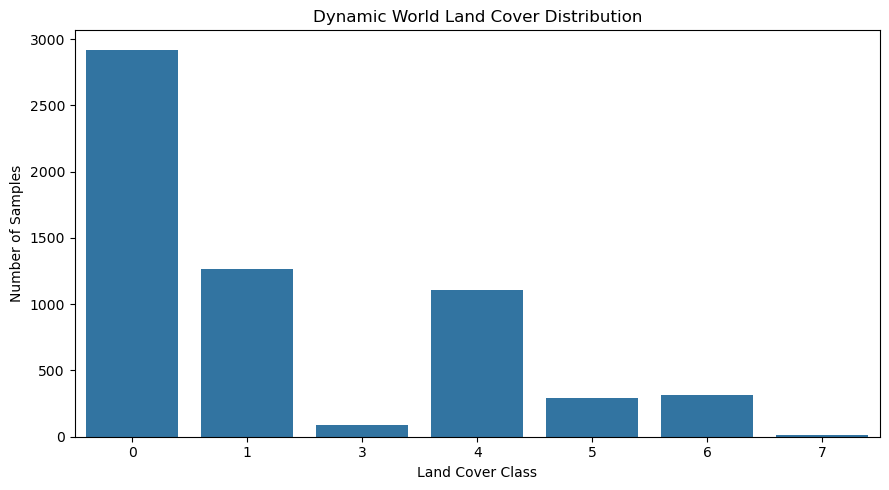

In [17]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="LandCover",
    order=sorted(df["LandCover"].unique())
)

plt.title(
    "Dynamic World Land Cover Distribution"
)

plt.xlabel(
    "Land Cover Class"
)

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()

plt.show()

15. Feature distribution plots

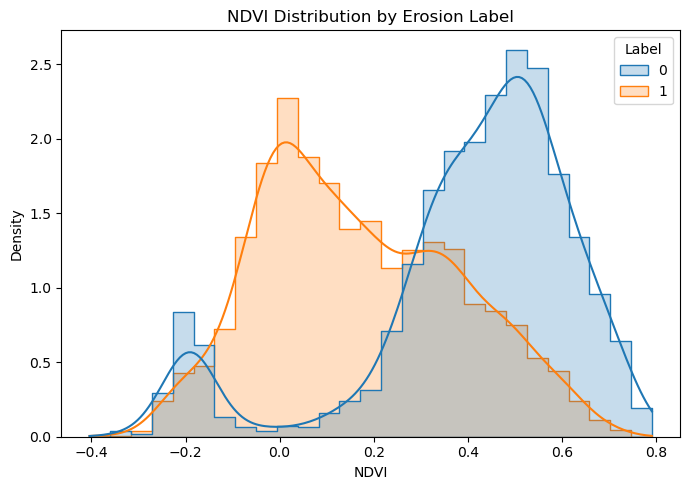

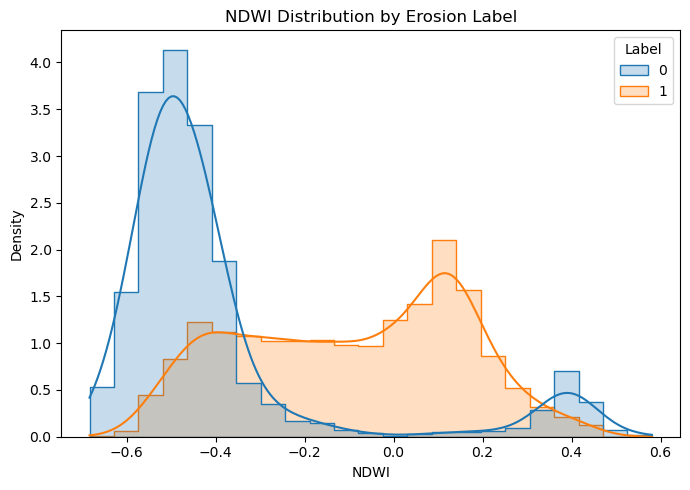

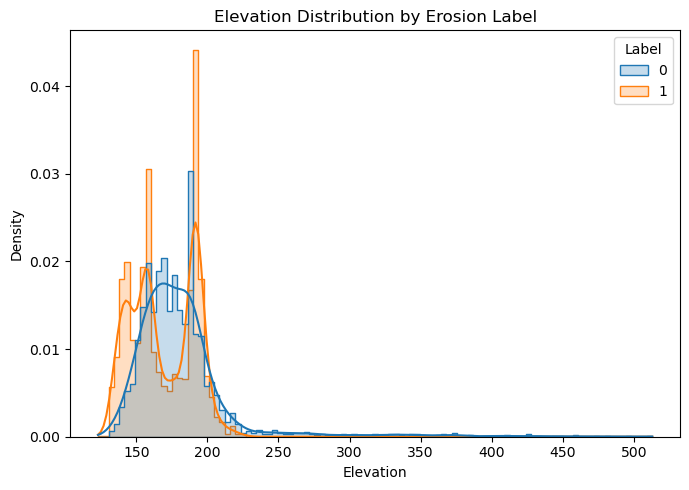

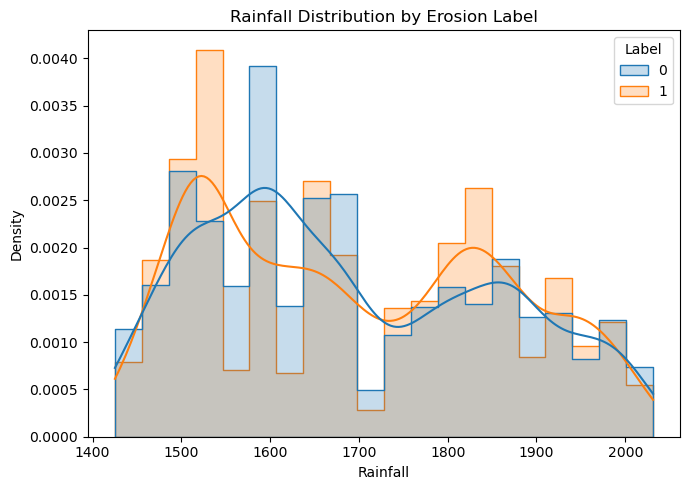

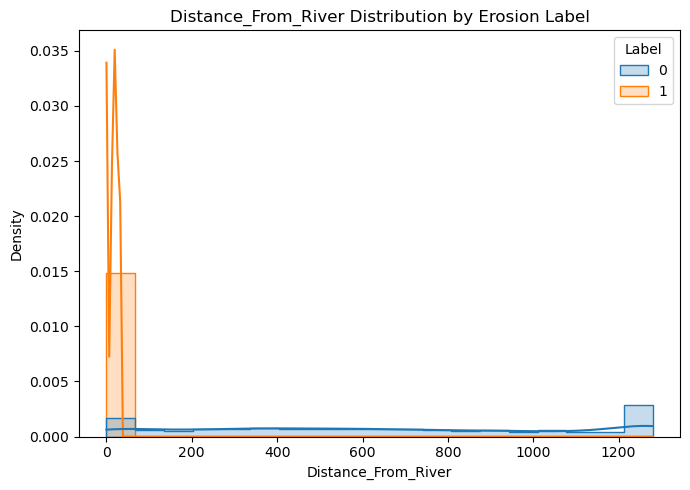

In [18]:
for feature in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Label",
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(
        f"{feature} Distribution by Erosion Label"
    )

    plt.xlabel(feature)

    plt.ylabel("Density")

    plt.tight_layout()

    plt.show()

16. Boxplots for outlier detection

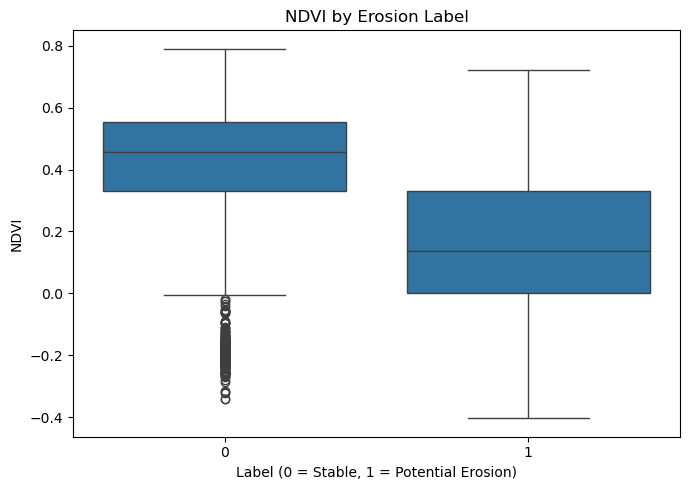

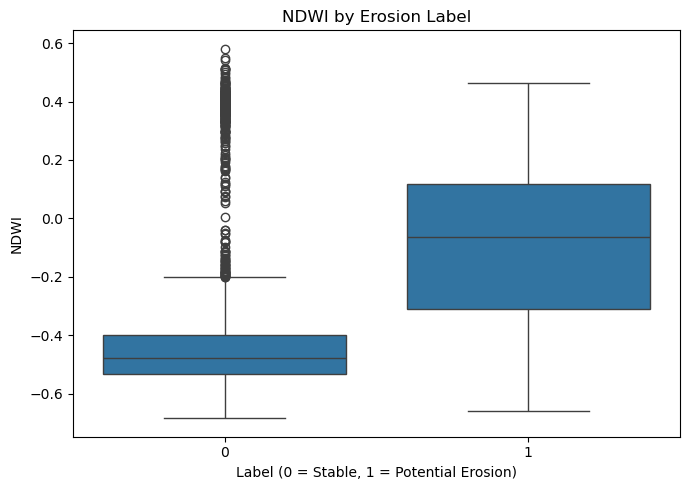

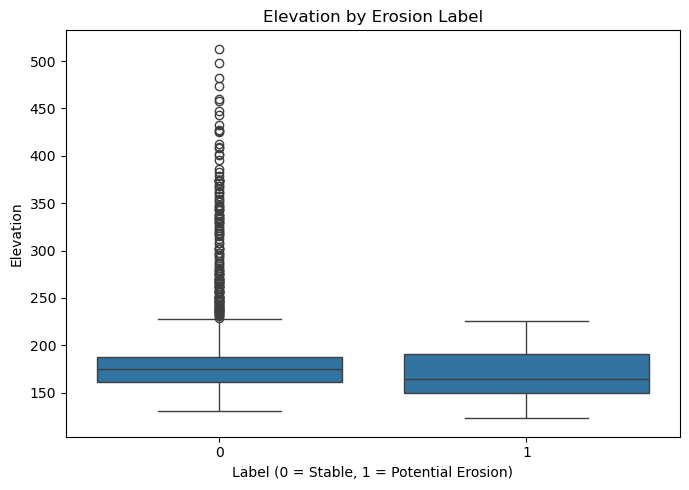

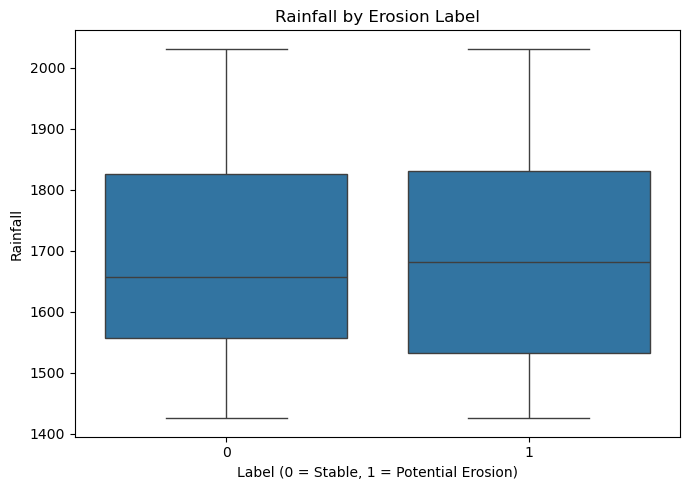

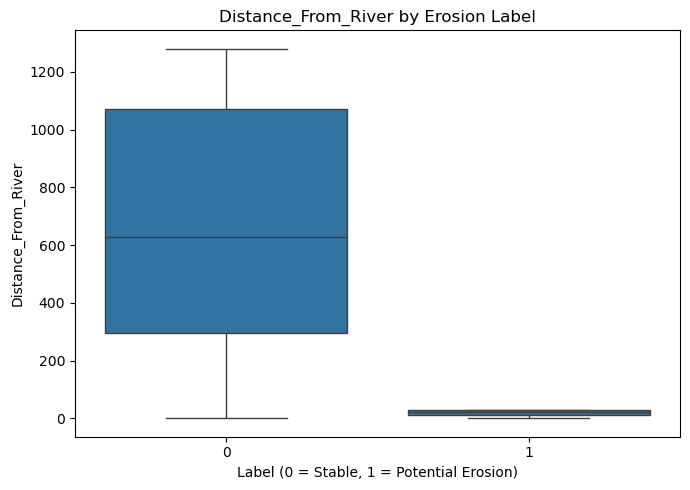

In [19]:
for feature in numerical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Label",
        y=feature
    )

    plt.title(
        f"{feature} by Erosion Label"
    )

    plt.xlabel(
        "Label (0 = Stable, 1 = Potential Erosion)"
    )

    plt.ylabel(feature)

    plt.tight_layout()

    plt.show()

17. Correlation matrix

In [20]:
correlation_features = [
    "NDVI",
    "NDWI",
    "Elevation",
    "Rainfall",
    "LandCover",
    "Distance_From_River",
    "Label"
]

correlation_matrix = (
    df[correlation_features]
    .corr()
)

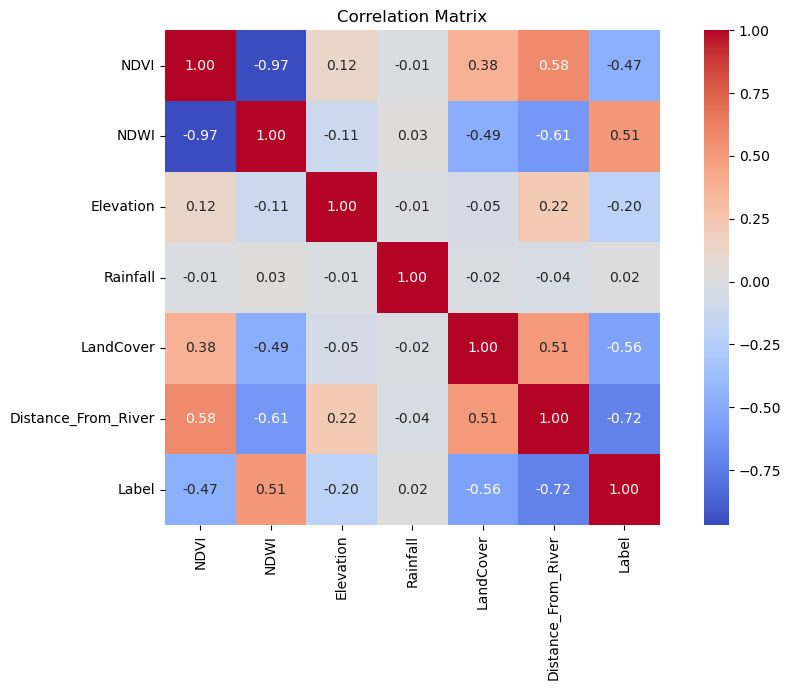

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.show()


18. Check extreme values

In [22]:
print("EXTREME VALUES")
for feature in numerical_features:

    print("\n", feature)

    print(
        "Minimum:",
        df[feature].min()
    )

    print(
        "Maximum:",
        df[feature].max()
    )

    print(
        "Mean:",
        df[feature].mean()
    )

    print(
        "Median:",
        df[feature].median()
    )

EXTREME VALUES

 NDVI
Minimum: -0.40392342
Maximum: 0.79064727
Mean: 0.2874804015694733
Median: 0.33031817

 NDWI
Minimum: -0.6835922
Maximum: 0.58038145
Mean: -0.24427623257342498
Median: -0.37021161999999996

 Elevation
Minimum: 123
Maximum: 513
Mean: 175.126
Median: 172.0

 Rainfall
Minimum: 1425.125935792923
Maximum: 2031.3388504182512
Mean: 1692.7651166615642
Median: 1660.8073947429657

 Distance_From_River
Minimum: 0.0
Maximum: 1280.0
Mean: 339.2132123594761
Median: 30.0


19. IQR outlier detection

In [23]:
print("IQR OUTLIER CHECK")
for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)

    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print(
        f"{feature}: {len(outliers)} outliers"
    )

IQR OUTLIER CHECK
NDVI: 0 outliers
NDWI: 0 outliers
Elevation: 126 outliers
Rainfall: 0 outliers
Distance_From_River: 0 outliers


20. Define ML features and target

In [24]:
FEATURES = [
    "NDVI",
    "NDWI",
    "Elevation",
    "Rainfall",
    "LandCover",
    "Distance_From_River"
]

TARGET = "Label"


In [25]:
X = df[FEATURES].copy()

y = df[TARGET].copy()

In [26]:
print("ML DATA")
print("X shape:", X.shape)

print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

ML DATA
X shape: (6000, 6)
y shape: (6000,)

Features:
['NDVI', 'NDWI', 'Elevation', 'Rainfall', 'LandCover', 'Distance_From_River']


21. Landcover as categorical

In [27]:
X["LandCover"] = X["LandCover"].astype(str)

22. TEMPORAL TRAIN / TEST SPLIT
Training:
2018→2019
2019→2020
2020→2021
2021→2022

Testing:
2022→2023
2023→2024

This prevents future years from being used to
predict earlier years.

In [28]:
train_mask = (
    df["Feature_Year"] <= 2021
)

test_mask = (
    df["Feature_Year"] >= 2022
)


In [29]:
X_train = X[train_mask].copy()

X_test = X[test_mask].copy()

y_train = y[train_mask].copy()

y_test = y[test_mask].copy()

In [30]:
print("TEMPORAL TRAIN / TEST SPLIT")
print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Training years:",
    sorted(
        df.loc[
            train_mask,
            "Feature_Year"
        ].unique()
    )
)

print(
    "Testing years:",
    sorted(
        df.loc[
            test_mask,
            "Feature_Year"
        ].unique()
    )
)

TEMPORAL TRAIN / TEST SPLIT
Training rows: 4000
Testing rows: 2000
Training years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Testing years: [np.int64(2022), np.int64(2023)]


23. Check class balance after split

In [31]:
print("\nTraining class distribution:")

print(
    y_train.value_counts()
    .sort_index()
)


print("\nTesting class distribution:")

print(
    y_test.value_counts()
    .sort_index()
)


Training class distribution:
Label
0    2000
1    2000
Name: count, dtype: int64

Testing class distribution:
Label
0    1000
1    1000
Name: count, dtype: int64


24. Preprocessing

In [32]:
categorical_features = [
    "LandCover"
]

numeric_features = [
    "NDVI",
    "NDWI",
    "Elevation",
    "Rainfall",
    "Distance_From_River"
]


In [33]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            StandardScaler(),

            numeric_features
        ),

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),

            categorical_features
        )

    ]
)

25. Fit preprocessor only on training data

In [34]:
X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)


X_test_processed = (
    preprocessor.transform(
        X_test
    )
)

26. Get feature values

In [35]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)
print("PROCESSED FEATURES")
print(
    feature_names
)

PROCESSED FEATURES
['numeric__NDVI' 'numeric__NDWI' 'numeric__Elevation' 'numeric__Rainfall'
 'numeric__Distance_From_River' 'categorical__LandCover_0'
 'categorical__LandCover_1' 'categorical__LandCover_3'
 'categorical__LandCover_4' 'categorical__LandCover_5'
 'categorical__LandCover_6' 'categorical__LandCover_7']


27. Convert to dataframes

In [36]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)


X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

28. Final preproceesed dataset information

In [37]:
print("\nProcessed training shape:")

print(
    X_train_processed.shape
)


print("\nProcessed testing shape:")

print(
    X_test_processed.shape
)



Processed training shape:
(4000, 12)

Processed testing shape:
(2000, 12)


print("\nFirst 5 processed training rows:")

print(
    X_train_processed.head()
)

29. Save processed data

In [38]:
X_train_processed.to_csv(
    "X_train_processed.csv",
    index=False
)

X_test_processed.to_csv(
    "X_test_processed.csv",
    index=False
)

y_train.to_csv(
    "y_train.csv",
    index=False
)

y_test.to_csv(
    "y_test.csv",
    index=False
)

30. Save feature names

In [39]:
feature_names_df = pd.DataFrame({
    "Feature": feature_names
})

feature_names_df.to_csv(
    "processed_feature_names.csv",
    index=False
)
print("PREPROCESSING COMPLETE")
print(
    "Saved files:"
)

print(
    "1. X_train_processed.csv"
)

print(
    "2. X_test_processed.csv"
)

print(
    "3. y_train.csv"
)

print(
    "4. y_test.csv"
)

print(
    "5. processed_feature_names.csv"
)

PREPROCESSING COMPLETE
Saved files:
1. X_train_processed.csv
2. X_test_processed.csv
3. y_train.csv
4. y_test.csv
5. processed_feature_names.csv
